In [9]:
import pandas as pd
from datasets import load_dataset

dataset = load_dataset("tundesta18/sales-forecast-dataset")
df=dataset['train'].to_pandas()
df.columns=df.columns.str.lower()

Repo card metadata block was not found. Setting CardData to empty.


In [10]:
df['product_sugar_content']=df['product_sugar_content'].replace({'reg':'High Sugar'})

### Sugar Contents VS Sales

In [11]:
# Are the People Consuming the More Sugar Products or the Low Sugar Products.Lets find out which sugar content is driving the sales in the store.
sugar_content=df.pivot_table(index='product_sugar_content',values='product_store_sales_total',aggfunc='sum')
sugar_content=sugar_content.sort_values(by='product_store_sales_total',ascending=False)
sugar_content

,product_store_sales_total
product_sugar_content,
Low Sugar,13116502.56
Regular,6124104.94
No Sugar,4146859.11
High Sugar,294139.72


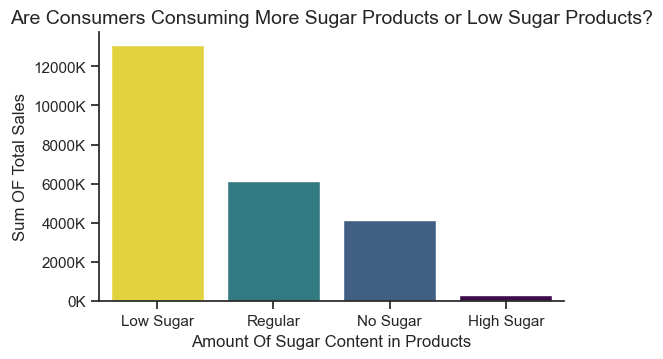

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
fig,ax=plt.subplots(figsize=(6,3.5))
sns.set_style('whitegrid')
sns.barplot(data=sugar_content,
            x=sugar_content.index,
            y='product_store_sales_total',
            hue='product_store_sales_total',
            palette='viridis',
            ax=ax,
            legend=False,
            dodge=False)
sns.despine()
plt.title('Are Consumers Consuming More Sugar Products or Low Sugar Products?',fontsize=14)
plt.xlabel('Amount Of Sugar Content in Products',fontsize=12)
plt.ylabel('Sum OF Total Sales',fontsize=12)
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x,pos:f'{x/1000:.0f}K')
)

### Product Weight VS Total Sales

In [15]:
# Does High Weighted Product Generates the More Sales?
product_weight=df.pivot_table(index='product_weight',values='product_store_sales_total',aggfunc='sum')
product_weight=product_weight.sort_values(by='product_store_sales_total',ascending=False).head(20)
product_weight=product_weight.reset_index()
product_weight

,product_weight,product_store_sales_total
0,13.23,87707.30
1,12.92,80906.60
2,12.95,79010.99
3,11.43,78129.95
4,12.57,74278.91
5,12.84,73910.83
6,12.51,72505.90
7,12.64,72034.58
8,11.15,70156.78
9,13.07,69811.45


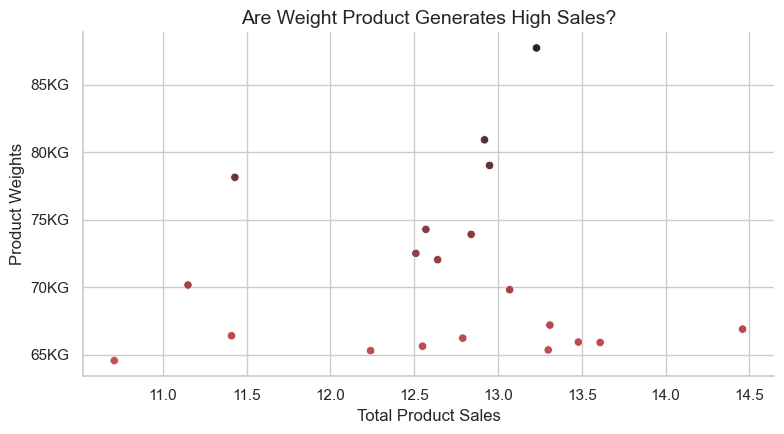

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
fig,ax=plt.subplots(1,1,figsize=(8,4.5))
sns.set_theme(style='ticks')
sns.scatterplot(data=product_weight,
                x='product_weight',
                y='product_store_sales_total',
                hue='product_store_sales_total',
                palette='dark:r_r',
                legend=False)
sns.despine()
plt.title('Are Weight Product Generates High Sales?',fontsize=14)
plt.xlabel('Total Product Sales',fontsize=12)
plt.ylabel('Product Weights',fontsize=12)
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x,pos:f'{x/1000:.0f}KG')
)
plt.tight_layout()
plt.show()